# NGA Painting Similarity Pipeline
## Google Colab T4 — Full Stack

**Stack:** SigLIP ViT-L/16-384 · DINOv2-large · YOLOv8-pose · LoRA/PEFT · Cross-Attention Fusion · FAISS IVF-PQ

| Step | Description | Est. time (T4) |
|------|-------------|----------------|
| 1 | Install dependencies | 3 min |
| 2 | NGA dataset download | 30–45 min |
| 3 | Image preprocessing & validation | 5 min |
| 4 | SigLIP + DINOv2 embedding extraction | 25 min |
| 5 | YOLOv8 pose extraction | 15 min |
| 6 | LoRA fine-tuning (SigLIP + triplet loss) | 45 min |
| 7 | Cross-attention fusion head | 10 min |
| 8 | FAISS IVF-PQ index build | 3 min |
| 9 | Query interface demo | — |
| 10 | Evaluation metrics | 5 min |

> **Before you start:** Runtime → Change runtime type → T4 GPU

---
## Step 1 — Install Dependencies
> Run this cell once, then **restart the runtime** (Runtime → Restart runtime).

In [1]:
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q "transformers>=4.45.0" "peft>=0.12.0" accelerate bitsandbytes datasets
!pip install -q ultralytics opencv-python-headless pillow albumentations
!pip install -q faiss-gpu-cu12
!pip install -q pandas numpy scipy scikit-learn requests tqdm wandb matplotlib seaborn

print('\n✓ Done. RESTART THE RUNTIME now before continuing.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 21.6 MB/s eta 0:00:00

✓ Done. RESTART THE RUNTIME now before continuing.


### Verify installation (run after restart)

In [1]:
import torch, transformers, peft, accelerate, ultralytics, faiss, wandb
import pandas, numpy, sklearn

print(f'PyTorch:       {torch.__version__}')
print(f'Transformers:  {transformers.__version__}')
print(f'PEFT:          {peft.__version__}')
print(f'Ultralytics:   {ultralytics.__version__}')
print(f'FAISS:         {faiss.__version__}')

if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'\nGPU:  {name}')
    print(f'VRAM: {vram:.1f} GB')
    assert vram >= 14, 'Need at least 14 GB VRAM — switch to T4 in runtime settings'
    print('✓ T4 detected — ready to proceed')
else:
    print('⚠ No GPU detected — switch to T4 GPU in runtime settings')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch:       2.10.0+cu128
Transformers:  5.0.0
PEFT:          0.18.1
Ultralytics:   8.4.24
FAISS:         1.14.1

GPU:  Tesla T4
VRAM: 15.6 GB
✓ T4 detected — ready to proceed


In [2]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE_FOLDER = 'painting_similarity'   # ← change this if you want
ROOT_DIR = f'/content/drive/MyDrive/{DRIVE_FOLDER}'

Mounted at /content/drive


---
## Step 2 — Configuration
All hyperparameters in one place. Adjust here before running downstream cells.

In [3]:
import os, random
import numpy as np
import torch

# ── Paths ─────────────────────────────────────────────────────────────────
ROOT_DIR   = '/content/painting_similarity'
DATA_DIR   = f'{ROOT_DIR}/data'
IMG_DIR    = f'{DATA_DIR}/images'
EMBED_DIR  = f'{ROOT_DIR}/embeddings'
CKPT_DIR   = f'{ROOT_DIR}/checkpoints'
INDEX_DIR  = f'{ROOT_DIR}/index'
RESULTS_DIR= f'{ROOT_DIR}/results'

MASTER_CSV    = f'{DATA_DIR}/master_dataset.csv'
SIGLIP_EMBED  = f'{EMBED_DIR}/siglip_embeddings.npy'
DINO_EMBED    = f'{EMBED_DIR}/dino_embeddings.npy'
POSE_EMBED    = f'{EMBED_DIR}/pose_embeddings.npy'
FUSED_EMBED   = f'{EMBED_DIR}/fused_embeddings.npy'
EMBED_IDS     = f'{EMBED_DIR}/object_ids.npy'
FAISS_INDEX   = f'{INDEX_DIR}/painting_index.faiss'
FAISS_META    = f'{INDEX_DIR}/index_metadata.pkl'

for d in [DATA_DIR,IMG_DIR,EMBED_DIR,CKPT_DIR,INDEX_DIR,RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Hardware ──────────────────────────────────────────────────────────────
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_FP16 = True
SEED     = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── Models ────────────────────────────────────────────────────────────────
SIGLIP_MODEL    = 'google/siglip-large-patch16-384'
DINO_MODEL      = 'facebook/dinov2-large'
YOLO_POSE_MODEL = 'yolov8l-pose.pt'

# ── Preprocessing ─────────────────────────────────────────────────────────
SIGLIP_IMG_SIZE = 384
DINO_IMG_SIZE   = 518
MIN_IMG_DIM     = 64

# ── Data ──────────────────────────────────────────────────────────────────
MAX_IMAGES       = 50_000   # Set to None for full 130K dataset
DOWNLOAD_WORKERS = 8
DOWNLOAD_TIMEOUT = 15

# ── Embeddings ────────────────────────────────────────────────────────────
EMBED_BATCH_SIZE = 32
EMBED_DIM_SIGLIP = 1024
EMBED_DIM_DINO   = 1024
POSE_KEYPOINTS   = 17
POSE_EMBED_DIM   = 34

# ── LoRA fine-tuning ──────────────────────────────────────────────────────
LORA_R              = 16
LORA_ALPHA          = 32
LORA_DROPOUT        = 0.1
LORA_TARGET_MODULES = ['q_proj', 'v_proj', 'k_proj', 'out_proj']
TRAIN_BATCH_SIZE    = 32
GRAD_ACCUM_STEPS    = 4
LEARNING_RATE       = 2e-4
WEIGHT_DECAY        = 0.01
WARMUP_STEPS        = 200
MAX_TRAIN_STEPS     = 3000
SAVE_EVERY_N_STEPS  = 500
TRIPLET_MARGIN      = 0.3

# ── Fusion ────────────────────────────────────────────────────────────────
FUSION_HIDDEN_DIM = 512
FUSION_OUTPUT_DIM = 512
FUSION_N_HEADS    = 8
FUSION_DROPOUT    = 0.1
FUSION_BATCH_SIZE = 64

# ── FAISS ─────────────────────────────────────────────────────────────────
FAISS_NLIST  = 256
FAISS_M_PQ   = 64
FAISS_NBITS  = 8
FAISS_NPROBE = 32

# ── Eval ──────────────────────────────────────────────────────────────────
TOP_K         = 20
EVAL_K_VALUES = [1, 5, 10, 20]
EVAL_N_QUERIES= 500

# ── W&B (optional) ────────────────────────────────────────────────────────
WANDB_PROJECT = 'nga-painting-similarity'

print(f'Device: {DEVICE}  |  fp16: {USE_FP16}')
print('✓ Configuration loaded')

Device: cuda  |  fp16: True
✓ Configuration loaded


---
## Step 3 — NGA Dataset Collection
Downloads `objects.csv` and `published_images.csv` from the NGA GitHub repo,
joins them, filters to paintings, and downloads the actual image files in parallel.

⏱ **~30–45 min** depending on network speed.

In [4]:
import requests, time
import pandas as pd
from io import BytesIO
from pathlib import Path
from PIL import Image, ImageFile
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True

NGA_BASE = 'https://raw.githubusercontent.com/NationalGalleryOfArt/opendata/main/data'

def download_csv(filename, url):
    dest = Path(DATA_DIR) / filename
    if dest.exists():
        print(f'  [cached] {filename}')
        return pd.read_csv(dest, low_memory=False)
    print(f'  Downloading {filename}...')
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    dest.write_bytes(r.content)
    print(f'  Saved {filename} ({len(r.content)/1e6:.1f} MB)')
    return pd.read_csv(BytesIO(r.content), low_memory=False)

objects_df = download_csv('objects.csv',          f'{NGA_BASE}/objects.csv')
images_df  = download_csv('published_images.csv', f'{NGA_BASE}/published_images.csv')

objects_df.columns = [c.strip().lower() for c in objects_df.columns]
images_df.columns  = [c.strip().lower() for c in images_df.columns]

print(f'\nobjects.csv rows:          {len(objects_df):,}')
print(f'published_images.csv rows: {len(images_df):,}')
print(f'objects columns: {list(objects_df.columns)}')

  Saved objects.csv (81.1 MB)
  Saved published_images.csv (39.6 MB)

objects.csv rows:          144,192
published_images.csv rows: 130,938
objects columns: ['objectid', 'uuid', 'accessioned', 'accessionnum', 'locationid', 'title', 'displaydate', 'beginyear', 'endyear', 'visualbrowsertimespan', 'medium', 'dimensions', 'inscription', 'markings', 'attributioninverted', 'attribution', 'provenancetext', 'creditline', 'classification', 'subclassification', 'visualbrowserclassification', 'parentid', 'isvirtual', 'departmentabbr', 'portfolio', 'series', 'volume', 'watermarks', 'lastdetectedmodification', 'wikidataid', 'customprinturl']


In [5]:
# ── Join using correct column names from NGA CSV ───────────────────────────
img_url_col = 'iiifthumburl'
img_id_col  = 'depictstmsobjectid'   # this is the foreign key to objects.csv
obj_id_col  = 'objectid'

print(f'Joining on: images.{img_id_col} → objects.{obj_id_col}')

obj_cols = [c for c in [obj_id_col, 'title', 'attribution', 'displaydate',
            'classification', 'medium', 'subjectterms', 'nationality']
            if c in objects_df.columns]
objects_clean = objects_df[obj_cols].copy()

images_clean = images_df[[img_id_col, img_url_col]].copy()
images_clean = images_clean.rename(columns={img_id_col: 'objectid', img_url_col: 'image_url'})
images_clean = images_clean.groupby('objectid', as_index=False).first()

master = objects_clean.merge(images_clean, on='objectid', how='inner')
print(f'After join: {len(master):,} paintings with images')

if 'classification' in master.columns:
    master = master[master['classification'].str.lower().str.contains('painting', na=False)]
    print(f'After painting filter: {len(master):,}')

master = master.dropna(subset=['image_url'])
master = master[master['image_url'].str.startswith('http')]
master = master.reset_index(drop=True)

if MAX_IMAGES and len(master) > MAX_IMAGES:
    master = master.sample(n=MAX_IMAGES, random_state=SEED).reset_index(drop=True)
    print(f'Dev cap applied: {MAX_IMAGES:,} paintings')

print(f'\n✓ Final dataset: {len(master):,} paintings')
master.head(3)

Joining on: images.depictstmsobjectid → objects.objectid
After join: 118,074 paintings with images
After painting filter: 4,038

✓ Final dataset: 4,038 paintings


,objectid,title,attribution,displaydate,classification,medium,image_url
0,0,Saint James Major,Grifo di Tancredi,c. 1310,Painting,tempera on panel,https://api.nga.gov/iiif/7b170a4c-9d44-475c-b2...
1,1,Saint Paul and a Group of Worshippers,Bernardo Daddi,1333,Painting,tempera on panel,https://api.nga.gov/iiif/7bbcfd01-e774-46e7-96...
2,2,Saint Andrew and Saint Benedict with the Archa...,Agnolo Gaddi,shortly before 1387,Painting,tempera on poplar panel,https://api.nga.gov/iiif/e8a1acb4-f60a-477a-9b...


In [6]:
# ── Build download URLs and download images ───────────────────────────────
def build_url(raw_url, size=512):
    if not isinstance(raw_url, str): return raw_url
    base = raw_url.split('/full/')[0] if '/full/' in raw_url else raw_url.rstrip('/')
    return f'{base}/full/!{size},{size}/0/default.jpg'

master['download_url'] = master['image_url'].apply(lambda u: build_url(u, 512))
master['local_path']   = master['objectid'].apply(
    lambda oid: str(Path(IMG_DIR) / f'{oid}.jpg'))

def download_one(row):
    oid, url, path = row['objectid'], row['download_url'], row['local_path']
    if Path(path).exists(): return (oid, 'cached')
    for attempt in range(3):
        try:
            r = requests.get(url, timeout=DOWNLOAD_TIMEOUT, stream=True)
            if r.status_code == 404: return (oid, 'not_found')
            r.raise_for_status()
            img = Image.open(BytesIO(r.content)).convert('RGB')
            if min(img.size) < MIN_IMG_DIM: return (oid, 'too_small')
            img.save(path, 'JPEG', quality=90)
            return (oid, 'ok')
        except Exception as e:
            if attempt == 2: return (oid, f'err:{str(e)[:30]}')
            time.sleep(0.5)

rows = master.to_dict('records')
results = []
with ThreadPoolExecutor(max_workers=DOWNLOAD_WORKERS) as ex:
    futures = {ex.submit(download_one, r): r for r in rows}
    for f in tqdm(as_completed(futures), total=len(futures), desc='Downloading images'):
        results.append(f.result())

status = pd.DataFrame(results, columns=['objectid','status'])
print(status['status'].value_counts().to_string())

ok_ids = set(status[status['status'].isin(['ok','cached'])]['objectid'])
master_clean = master[master['objectid'].isin(ok_ids)].reset_index(drop=True)
master_clean.to_csv(MASTER_CSV, index=False)
print(f'\n✓ {len(master_clean):,} paintings ready  →  {MASTER_CSV}')

status
ok                                    4013
err:HTTPSConnectionPool(host='api.      24
not_found                                1

✓ 4,013 paintings ready  →  /content/painting_similarity/data/master_dataset.csv


---
## Step 4 — Image Preprocessing & Dataset Class
Defines the transforms for both models and the `PaintingDataset` used throughout the pipeline.

In [7]:
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Optional, Callable, Dict, List

SIGLIP_MEAN = [0.5, 0.5, 0.5]
SIGLIP_STD  = [0.5, 0.5, 0.5]
DINO_MEAN   = [0.485, 0.456, 0.406]
DINO_STD    = [0.229, 0.224, 0.225]

def get_siglip_transform(augment=False):
    base = [
        transforms.Resize((SIGLIP_IMG_SIZE, SIGLIP_IMG_SIZE),
                           interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(SIGLIP_MEAN, SIGLIP_STD),
    ]
    if augment:
        return transforms.Compose([
            transforms.Resize((SIGLIP_IMG_SIZE, SIGLIP_IMG_SIZE),
                               interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomApply([transforms.ColorJitter(0.2,0.2,0.1)], p=0.3),
            transforms.ToTensor(),
            transforms.Normalize(SIGLIP_MEAN, SIGLIP_STD),
        ])
    return transforms.Compose(base)

def get_dino_transform(augment=False):
    return transforms.Compose([
        transforms.Resize((DINO_IMG_SIZE, DINO_IMG_SIZE),
                           interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(DINO_MEAN, DINO_STD),
    ])

class PaintingDataset(Dataset):
    def __init__(self, df, transform=None, mode='embed', model='siglip'):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.mode = mode
        self.model = model
        if mode == 'triplet': self._build_tag_index()

    def _build_tag_index(self):
        self.tag_to_indices = {}
        col = 'subjectterms' if 'subjectterms' in self.df.columns else 'classification'
        for idx, row in self.df.iterrows():
            for tag in str(row.get(col,'')).lower().split('|'):
                tag = tag.strip()
                if tag: self.tag_to_indices.setdefault(tag,[]).append(idx)
        self.tag_to_indices = {t:v for t,v in self.tag_to_indices.items() if len(v)>=2}
        self.valid_indices = list(set(i for v in self.tag_to_indices.values() for i in v))

    def _load(self, path):
        try: return Image.open(path).convert('RGB')
        except:
            sz = SIGLIP_IMG_SIZE if self.model=='siglip' else DINO_IMG_SIZE
            return Image.new('RGB',(sz,sz),(0,0,0))

    def __len__(self):
        return len(self.valid_indices) if self.mode=='triplet' else len(self.df)

    def __getitem__(self, idx):
        if self.mode == 'triplet': return self._triplet(idx)
        row = self.df.iloc[idx]
        img = self._load(str(row['local_path']))
        tensor = self.transform(img) if self.transform else transforms.ToTensor()(img)
        return {'pixel_values': tensor, 'objectid': str(row['objectid']), 'idx': idx}

    def _triplet(self, idx):
        import random as rnd
        anchor_idx = self.valid_indices[idx]
        anchor_row = self.df.iloc[anchor_idx]
        col = 'subjectterms' if 'subjectterms' in self.df.columns else 'classification'
        anchor_tags = {t.strip().lower() for t in str(anchor_row.get(col,'')).split('|') if t.strip()}
        shared = [t for t in anchor_tags if t in self.tag_to_indices]
        if shared:
            pool = [i for i in self.tag_to_indices[rnd.choice(shared)] if i != anchor_idx]
            pos_idx = rnd.choice(pool) if pool else anchor_idx
        else: pos_idx = anchor_idx
        neg_pool = self.df[~self.df.index.isin([anchor_idx, pos_idx])].index.tolist()
        neg_idx = rnd.choice(neg_pool) if neg_pool else 0
        def lt(i):
            row = self.df.iloc[i]
            img = self._load(str(row['local_path']))
            return self.transform(img) if self.transform else transforms.ToTensor()(img)
        return {'anchor': lt(anchor_idx), 'positive': lt(pos_idx), 'negative': lt(neg_idx),
                'anchor_id': str(anchor_row['objectid']),
                'positive_id': str(self.df.iloc[pos_idx]['objectid']),
                'negative_id': str(self.df.iloc[neg_idx]['objectid'])}

# Validate images
df = pd.read_csv(MASTER_CSV, low_memory=False)
bad = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc='Validating'):
    p = str(row.get('local_path',''))
    if not Path(p).exists(): bad.append(idx); continue
    try:
        img = Image.open(p); img.verify()
        img = Image.open(p).convert('RGB')
        if min(img.size) < MIN_IMG_DIM: bad.append(idx)
    except: bad.append(idx)

df = df.drop(index=bad).reset_index(drop=True)
df.to_csv(MASTER_CSV, index=False)
print(f'✓ Validation complete: {len(df):,} clean images  ({len(bad)} removed)')

Validating:   0%|          | 0/4013 [00:00<?, ?it/s]

✓ Validation complete: 4,013 clean images  (0 removed)


---
## Step 5 — Embedding Extraction: SigLIP + DINOv2
Runs both vision encoders over all paintings in fp16 and saves embedding arrays.

⏱ **~25 min** · VRAM peak ~6 GB

In [8]:
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import AutoModel, AutoProcessor

@torch.no_grad()
def extract_embeddings(model, loader, stream, device):
    all_embs, all_ids = [], []
    for batch in tqdm(loader, desc=f'{stream} embeddings'):
        pv = batch['pixel_values'].to(device)
        if USE_FP16: pv = pv.half()
        if stream == 'siglip':
            out = model.vision_model(pixel_values=pv)
            emb = F.normalize(out.pooler_output.float(), dim=-1)
        else:  # dino
            out = model(pixel_values=pv)
            emb = F.normalize(out.last_hidden_state[:,0,:].float(), dim=-1)
        all_embs.append(emb.cpu().numpy())
        all_ids.extend(batch['objectid'])
    return np.vstack(all_embs), all_ids

# ── SigLIP ────────────────────────────────────────────────────────────────
if Path(SIGLIP_EMBED).exists():
    print('[cached] SigLIP embeddings found')
    sig_embs = np.load(SIGLIP_EMBED)
    sig_ids  = list(np.load(EMBED_IDS, allow_pickle=True))
else:
    print('Loading SigLIP...')
    sig_model = AutoModel.from_pretrained(SIGLIP_MODEL,
                    torch_dtype=torch.float16 if USE_FP16 else torch.float32).to(DEVICE).eval()
    sig_ds  = PaintingDataset(df, transform=get_siglip_transform(), mode='embed', model='siglip')
    sig_ldr = DataLoader(sig_ds, batch_size=EMBED_BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
    sig_embs, sig_ids = extract_embeddings(sig_model, sig_ldr, 'siglip', DEVICE)
    np.save(SIGLIP_EMBED, sig_embs)
    np.save(EMBED_IDS, np.array(sig_ids, dtype=object))
    del sig_model; torch.cuda.empty_cache()
    print(f'✓ SigLIP embeddings saved  {sig_embs.shape}')

# ── DINOv2 ────────────────────────────────────────────────────────────────
if Path(DINO_EMBED).exists():
    print('[cached] DINOv2 embeddings found')
    dino_embs = np.load(DINO_EMBED)
else:
    print('Loading DINOv2...')
    dino_model = AutoModel.from_pretrained(DINO_MODEL,
                    torch_dtype=torch.float16 if USE_FP16 else torch.float32).to(DEVICE).eval()
    dino_ds  = PaintingDataset(df, transform=get_dino_transform(), mode='embed', model='dino')
    dino_ldr = DataLoader(dino_ds, batch_size=EMBED_BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
    dino_embs, _ = extract_embeddings(dino_model, dino_ldr, 'dino', DEVICE)
    np.save(DINO_EMBED, dino_embs)
    del dino_model; torch.cuda.empty_cache()
    print(f'✓ DINOv2 embeddings saved  {dino_embs.shape}')

print(f'SigLIP: {sig_embs.shape}  |  DINOv2: {dino_embs.shape}')

Loading SigLIP...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/554 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/549 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

dino embeddings:   0%|          | 0/126 [00:00<?, ?it/s]

✓ DINOv2 embeddings saved  (4013, 1024)
SigLIP: (4013, 1024)  |  DINOv2: (4013, 1024)


In [9]:
# ── Cosine similarity sanity check ────────────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

id_to_meta = {str(r['objectid']): r for _, r in df.iterrows()}
for _ in range(3):
    qi = random.randint(0, len(sig_ids)-1)
    qid = sig_ids[qi]
    sims = cos_sim(sig_embs[qi:qi+1], sig_embs)[0]
    top5 = np.argsort(-sims)[1:6]
    q = id_to_meta.get(qid, {})
    print(f"\nQuery: {str(q.get('title',''))[:50]}")
    print(f"Tags:  {str(q.get('subjectterms',''))[:60]}")
    for rank, ridx in enumerate(top5, 1):
        rid = sig_ids[ridx]
        r = id_to_meta.get(rid, {})
        print(f'  {rank}. [{sims[ridx]:.3f}] {str(r.get("title",""))[:45]}')


Query: No. 18
Tags:  
  1. [0.932] Untitled
  2. [0.926] No. 2
  3. [0.917] Untitled
  4. [0.910] Untitled
  5. [0.908] Untitled

Query: A Painter's Studio
Tags:  
  1. [0.775] The Corinthian Maid
  2. [0.773] The Visit to the Nursery
  3. [0.759] I Reread Them with Pleasure
  4. [0.745] Portrait of a Young Woman in White
  5. [0.740] The Little Schoolmistress

Query: Lady Mary Templetown and Her Eldest Son
Tags:  
  1. [0.816] The Frankland Sisters
  2. [0.802] Lady Elizabeth Delmé and Her Children
  3. [0.799] Miss Juliana Willoughby
  4. [0.791] Lady Caroline Howard
  5. [0.791] Mrs. Richard Brinsley Sheridan


---
## Step 6 — Pose Extraction: YOLOv8-large-pose
Detects 17 COCO body keypoints per painting. Keypoints are normalised
to be position- and scale-invariant, producing a 34-dim pose vector.

⏱ **~15 min** · VRAM ~1.2 GB

In [10]:
from ultralytics import YOLO

COCO_KPS = ['nose','l_eye','r_eye','l_ear','r_ear','l_shoulder','r_shoulder',
            'l_elbow','r_elbow','l_wrist','r_wrist','l_hip','r_hip',
            'l_knee','r_knee','l_ankle','r_ankle']

def extract_pose_vec(result, w, h, conf_thr=0.3):
    vec = np.zeros(POSE_EMBED_DIM, dtype=np.float32)
    if result.keypoints is None or len(result.keypoints)==0: return vec
    kdata = result.keypoints.data
    if kdata is None or kdata.shape[0]==0: return vec
    boxes = result.boxes
    if boxes is not None and len(boxes)>1:
        best = int((boxes.xywh[:,2]*boxes.xywh[:,3]).argmax().item())
    else: best=0
    kpts = kdata[best].cpu().numpy()
    for i in range(min(POSE_KEYPOINTS, kpts.shape[0])):
        x,y,c = kpts[i]
        if c>=conf_thr:
            vec[i*2]   = x/w
            vec[i*2+1] = y/h
    return vec

def norm_pose_vec(vec):
    xs, ys = vec[0::2], vec[1::2]
    ax, ay = xs[xs!=0], ys[ys!=0]
    if len(ax)==0: return vec
    cx, cy = ax.mean(), ay.mean()
    out = vec.copy()
    out[0::2] = np.where(xs!=0, xs-cx, 0.)
    out[1::2] = np.where(ys!=0, ys-cy, 0.)
    return out

if Path(POSE_EMBED).exists():
    print('[cached] Pose embeddings found')
    pose_embs = np.load(POSE_EMBED)
else:
    yolo = YOLO(YOLO_POSE_MODEL).to(DEVICE)
    paths   = df['local_path'].tolist()
    obj_ids = [str(x) for x in df['objectid'].tolist()]
    all_poses, n_det = [], 0
    for start in tqdm(range(0, len(paths), 16), desc='Pose extraction'):
        batch_p = paths[start:start+16]
        imgs    = []
        dims    = []
        for p in batch_p:
            try:
                img = Image.open(p).convert('RGB')
                imgs.append(img); dims.append((img.width,img.height))
            except:
                imgs.append(Image.new('RGB',(224,224))); dims.append((224,224))
        results = yolo.predict(source=imgs, conf=0.3, verbose=False,
                               device=DEVICE, imgsz=640)
        for res,(w,h) in zip(results, dims):
            v = norm_pose_vec(extract_pose_vec(res,w,h))
            all_poses.append(v)
            if v.sum()!=0: n_det+=1
    pose_embs = np.vstack(all_poses).astype(np.float32)
    np.save(POSE_EMBED, pose_embs)
    del yolo; torch.cuda.empty_cache()
    print(f'✓ Pose saved {pose_embs.shape}  |  figures detected: {n_det:,}/{len(paths):,}')

nz = (~(pose_embs==0).all(axis=1)).sum()
print(f'Pose vectors with detected figure: {nz:,} / {len(pose_embs):,} ({100*nz/len(pose_embs):.1f}%)')

Pose extraction:   0%|          | 0/251 [00:00<?, ?it/s]

✓ Pose saved (4013, 34)  |  figures detected: 2,320/4,013
Pose vectors with detected figure: 2,375 / 4,013 (59.2%)


---
## Step 7 — LoRA Fine-Tuning (SigLIP + Triplet Loss)
Adapts SigLIP to the art domain. Only ~2M of 307M parameters are trained.
Training automatically resumes after a Colab session disconnect.

⏱ **~45 min** · VRAM peak ~6 GB

In [11]:
import gc
import torch.nn as nn
from peft import LoraConfig, get_peft_model
from transformers import AutoModel, get_cosine_schedule_with_warmup
from torch.utils.data import DataLoader, random_split

torch.cuda.empty_cache()
gc.collect()

class TripletLoss(nn.Module):
    def __init__(self, margin=TRIPLET_MARGIN):
        super().__init__(); self.m = margin
    def forward(self, a, p, n):
        a,p,n = F.normalize(a,dim=-1), F.normalize(p,dim=-1), F.normalize(n,dim=-1)
        d_ap = (a-p).pow(2).sum(-1).clamp(1e-8).sqrt()
        d_an = (a-n).pow(2).sum(-1).clamp(1e-8).sqrt()
        return F.relu(d_ap - d_an + self.m).mean()

class SigLIPEmbedder(nn.Module):
    def __init__(self, vm): super().__init__(); self.vm = vm
    def forward(self, pv):
        return F.normalize(self.vm(pixel_values=pv).pooler_output.float(), dim=-1)

def build_lora_model():
    base = AutoModel.from_pretrained(SIGLIP_MODEL,
               torch_dtype=torch.float16 if USE_FP16 else torch.float32)
    lora_cfg = LoraConfig(
        r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET_MODULES, bias='none')
    vm = get_peft_model(base.vision_model, lora_cfg)
    vm.base_model.model.gradient_checkpointing_enable()  # saves ~50% activation memory
    vm.print_trainable_parameters()
    return SigLIPEmbedder(vm).to(DEVICE)

ACTUAL_BATCH = 4    # 3 forward passes per step (anchor+pos+neg) — keep this low
ACTUAL_ACCUM = 32   # effective batch = 4×32 = 128

final_adapter = Path(CKPT_DIR)/'final_lora_adapter'
if final_adapter.exists():
    print('[cached] Fine-tuned adapter found — skipping training')
else:
    embedder  = build_lora_model()
    criterion = TripletLoss()
    aug_tf    = get_siglip_transform(augment=True)
    full_ds   = PaintingDataset(df, transform=aug_tf, mode='triplet', model='siglip')
    val_n     = max(100, int(0.1*len(full_ds)))
    trn_ds, val_ds = random_split(full_ds, [len(full_ds)-val_n, val_n],
                          generator=torch.Generator().manual_seed(SEED))
    trn_ldr = DataLoader(trn_ds, batch_size=ACTUAL_BATCH, shuffle=True,
                         num_workers=2, pin_memory=True, drop_last=True)
    val_ldr = DataLoader(val_ds, batch_size=ACTUAL_BATCH, shuffle=False,
                         num_workers=2, pin_memory=True)
    opt    = torch.optim.AdamW(
        [p for p in embedder.parameters() if p.requires_grad],
        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    sch    = get_cosine_schedule_with_warmup(opt, WARMUP_STEPS, MAX_TRAIN_STEPS)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)

    step, best_val = 0, float('inf')
    ckpts = sorted(Path(CKPT_DIR).glob('step_*'))
    if ckpts:
        ck = torch.load(str(ckpts[-1])/'model.pt', map_location=DEVICE)
        embedder.load_state_dict(ck['model'])
        opt.load_state_dict(ck['opt'])
        step = ck['step']
        print(f'Resumed from step {step}')

    embedder.train()
    opt.zero_grad()
    run_loss = 0.0
    print(f'Training from step {step}/{MAX_TRAIN_STEPS}  |  batch={ACTUAL_BATCH}  |  accum={ACTUAL_ACCUM}')

    for epoch in range(9999):
        for batch in trn_ldr:
            if step >= MAX_TRAIN_STEPS: break
            with torch.cuda.amp.autocast(enabled=USE_FP16):
                a = embedder(batch['anchor'].to(DEVICE))
                p = embedder(batch['positive'].to(DEVICE))
                n = embedder(batch['negative'].to(DEVICE))
                loss = criterion(a, p, n) / ACTUAL_ACCUM
            scaler.scale(loss).backward()
            if (step + 1) % ACTUAL_ACCUM == 0:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(embedder.parameters(), 1.0)
                scaler.step(opt); scaler.update(); opt.zero_grad(); sch.step()
            run_loss += loss.item() * ACTUAL_ACCUM
            step += 1
            if step % 100 == 0:
                print(f'  step {step:4d} | loss={run_loss/100:.4f} | lr={sch.get_last_lr()[0]:.2e}')
                run_loss = 0.0
            if step % SAVE_EVERY_N_STEPS == 0:
                ck_path = Path(CKPT_DIR)/f'step_{step:05d}'
                ck_path.mkdir(exist_ok=True)
                torch.save({'model': embedder.state_dict(), 'opt': opt.state_dict(), 'step': step},
                           str(ck_path/'model.pt'))
                print(f'  [checkpoint saved — step {step}]')
        if step >= MAX_TRAIN_STEPS: break

    embedder.vm.save_pretrained(str(final_adapter))
    print(f'✓ Fine-tuning complete  →  {final_adapter}')
    del embedder; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

trainable params: 3,178,496 || all params: 319,462,400 || trainable%: 0.9950
Training from step 0/3000  |  batch=4  |  accum=32


/tmp/ipykernel_5368/1993361439.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)
/tmp/ipykernel_5368/1993361439.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_FP16):


  step  100 | loss=0.2944 | lr=3.00e-06
  step  200 | loss=0.3004 | lr=6.00e-06
  step  300 | loss=0.3106 | lr=9.00e-06
  step  400 | loss=0.2995 | lr=1.20e-05
  step  500 | loss=0.3063 | lr=1.50e-05
  [checkpoint saved — step 500]
  step  600 | loss=0.3055 | lr=1.80e-05
  step  700 | loss=0.2913 | lr=2.10e-05
  step  800 | loss=0.2971 | lr=2.50e-05
  step  900 | loss=0.2998 | lr=2.80e-05
  step 1000 | loss=0.3023 | lr=3.10e-05
  [checkpoint saved — step 1000]
  step 1100 | loss=0.3046 | lr=3.40e-05
  step 1200 | loss=0.3017 | lr=3.70e-05
  step 1300 | loss=0.2975 | lr=4.00e-05
  step 1400 | loss=0.3114 | lr=4.30e-05
  step 1500 | loss=0.3027 | lr=4.60e-05
  [checkpoint saved — step 1500]
  step 1600 | loss=0.2969 | lr=5.00e-05
  step 1700 | loss=0.3098 | lr=5.30e-05
  step 1800 | loss=0.3094 | lr=5.60e-05
  step 1900 | loss=0.3107 | lr=5.90e-05
  step 2000 | loss=0.3127 | lr=6.20e-05
  [checkpoint saved — step 2000]
  step 2100 | loss=0.2966 | lr=6.50e-05
  step 2200 | loss=0.2968 | l

/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in  - will assume that the vocabulary was not modified.
  warnings.warn(


In [13]:
# ── Free GPU memory from embedding models ──────────────────────────────────
import gc

try: del sig_model
except: pass
try: del dino_model
except: pass
try: del model
except: pass

torch.cuda.empty_cache()
gc.collect()

print(f'VRAM free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.2f} GB')

VRAM free: 15.51 GB


In [16]:
# ── Re-extract SigLIP embeddings with fine-tuned weights ──────────────────
from peft import PeftModel

if Path(SIGLIP_EMBED.replace('.npy','_finetuned.npy')).exists():
    print('[cached] Fine-tuned SigLIP embeddings exist')
else:
    print('Re-extracting with fine-tuned SigLIP...')
    base = AutoModel.from_pretrained(SIGLIP_MODEL, torch_dtype=torch.float16)
    ft_model = PeftModel.from_pretrained(base.vision_model, str(final_adapter))
    ft_model = ft_model.to(DEVICE).eval()
    sig_ds = PaintingDataset(df, transform=get_siglip_transform(), mode='embed', model='siglip')
    sig_ldr= DataLoader(sig_ds, batch_size=EMBED_BATCH_SIZE, shuffle=False, num_workers=2)
    all_embs = []
    with torch.no_grad():
        for batch in tqdm(sig_ldr, desc='Re-extracting SigLIP'):
            pv = batch['pixel_values'].to(DEVICE).half()
            out = ft_model(pixel_values=pv)
            emb = F.normalize(out.pooler_output.float(), dim=-1)
            all_embs.append(emb.cpu().numpy())
    sig_embs = np.vstack(all_embs)
    np.save(SIGLIP_EMBED, sig_embs)
    print(f'✓ Fine-tuned SigLIP embeddings saved  {sig_embs.shape}')
    del ft_model; torch.cuda.empty_cache()

Re-extracting with fine-tuned SigLIP...


Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

Re-extracting SigLIP:   0%|          | 0/126 [00:00<?, ?it/s]

✓ Fine-tuned SigLIP embeddings saved  (4013, 1024)


---
## Step 8 — Cross-Attention Fusion Head
Combines SigLIP (semantic) + DINOv2 (structural) + Pose (body keypoints)
into a single 512-dim vector via multi-head cross-attention.

⏱ **~10 min**

In [20]:
class CrossAttentionFusionHead(nn.Module):
    def __init__(self, siglip_dim=EMBED_DIM_SIGLIP, dino_dim=EMBED_DIM_DINO,
                 pose_dim=POSE_EMBED_DIM, d_model=FUSION_HIDDEN_DIM,
                 n_heads=FUSION_N_HEADS, output_dim=FUSION_OUTPUT_DIM, dropout=FUSION_DROPOUT):
        super().__init__()
        self.proj_sig  = nn.Sequential(nn.Linear(siglip_dim, d_model), nn.LayerNorm(d_model))
        self.proj_dino = nn.Sequential(nn.Linear(dino_dim, d_model),   nn.LayerNorm(d_model))
        self.proj_pose = nn.Sequential(
            nn.Linear(pose_dim, 128), nn.ReLU(), nn.Linear(128, d_model), nn.LayerNorm(d_model))
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True)
        self.transformer    = nn.TransformerEncoder(enc, num_layers=2)
        self.stream_weights = nn.Parameter(torch.ones(3) / 3)
        self.out_proj       = nn.Sequential(nn.Linear(d_model, output_dim), nn.LayerNorm(output_dim))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, sig, dino, pose):
        s     = self.proj_sig(sig).unsqueeze(1)
        d     = self.proj_dino(dino).unsqueeze(1)
        p     = self.proj_pose(pose).unsqueeze(1)
        seq   = torch.cat([s, d, p], dim=1)
        out   = self.transformer(seq)
        w     = F.softmax(self.stream_weights, dim=0)
        fused = (out * w.view(1, 3, 1)).sum(dim=1)
        return F.normalize(self.out_proj(fused), dim=-1)


head_path = Path(CKPT_DIR) / 'fusion_head.pt'

if Path(FUSED_EMBED).exists():
    print('[cached] Fused embeddings found')
    fused_embs = np.load(FUSED_EMBED)

else:
    # ── Build triplet supervision from tag labels ──────────────────────────
    col = 'subjectterms' if 'subjectterms' in df.columns else 'classification'

    tag_to_idx = {}
    for idx, row in df.iterrows():
        for t in str(row.get(col, '')).lower().split('|'):
            t = t.strip()
            if t:
                tag_to_idx.setdefault(t, []).append(idx)

    tag_to_idx = {t: v for t, v in tag_to_idx.items() if len(v) >= 2}
    valid_tags = list(tag_to_idx.keys())

    print(f'  Valid tags for triplet sampling: {len(valid_tags)}')
    for t in valid_tags:
        print(f'    "{t}": {len(tag_to_idx[t])} samples')

    all_indices = list(df.index)
    triplets    = []

    if len(valid_tags) < 2:
        # Fallback: single-class — sample 3 distinct indices at random
        print(f'  Warning: only {len(valid_tags)} tag(s) found. '
              f'Falling back to random index-based triplet sampling.')
        for _ in range(100_000):
            a, p, n = random.sample(all_indices, 3)
            triplets.append((a, p, n))
    else:
        # Normal: cross-class triplets
        other_tags = {t: [x for x in valid_tags if x != t] for t in valid_tags}
        for _ in range(100_000):
            t       = random.choice(valid_tags)
            a, p    = random.sample(tag_to_idx[t], 2)
            nt      = random.choice(other_tags[t])
            n       = random.choice(tag_to_idx[nt])
            triplets.append((a, p, n))

    # ── Train fusion head ──────────────────────────────────────────────────
    fusion_model = CrossAttentionFusionHead().to(DEVICE)
    crit = nn.TripletMarginLoss(margin=TRIPLET_MARGIN, p=2)
    opt  = torch.optim.AdamW(fusion_model.parameters(), lr=1e-3, weight_decay=1e-4)

    T_sig  = torch.from_numpy(np.load(SIGLIP_EMBED)).float()
    T_dino = torch.from_numpy(np.load(DINO_EMBED)).float()
    T_pose = torch.from_numpy(np.load(POSE_EMBED)).float()

    BS = FUSION_BATCH_SIZE
    for epoch in range(10):
        random.shuffle(triplets)
        total, nb = 0., 0
        for s in tqdm(range(0, len(triplets), BS), desc=f'Fusion epoch {epoch+1}/10', leave=False):
            b          = triplets[s:s+BS]
            ai, pi, ni = map(list, zip(*b))
            a = fusion_model(T_sig[ai].to(DEVICE), T_dino[ai].to(DEVICE), T_pose[ai].to(DEVICE))
            p = fusion_model(T_sig[pi].to(DEVICE), T_dino[pi].to(DEVICE), T_pose[pi].to(DEVICE))
            n = fusion_model(T_sig[ni].to(DEVICE), T_dino[ni].to(DEVICE), T_pose[ni].to(DEVICE))
            loss = crit(a, p, n)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(fusion_model.parameters(), 1.0)
            opt.step()
            total += loss.item(); nb += 1
        print(f'  Epoch {epoch+1}: loss={total/nb:.4f}')

    torch.save(fusion_model.state_dict(), str(head_path))

    # ── Generate all fused embeddings ──────────────────────────────────────
    fusion_model.eval()
    all_fused = []
    with torch.no_grad():
        for s in tqdm(range(0, len(T_sig), 512), desc='Fusing embeddings'):
            f = fusion_model(
                T_sig[s:s+512].to(DEVICE),
                T_dino[s:s+512].to(DEVICE),
                T_pose[s:s+512].to(DEVICE)
            )
            all_fused.append(f.cpu().numpy())

    fused_embs = np.vstack(all_fused).astype(np.float32)
    np.save(FUSED_EMBED, fused_embs)
    print(f'✓ Fused embeddings saved  {fused_embs.shape}')

print(f'Fused shape: {fused_embs.shape}  |  norm range: '
      f'[{np.linalg.norm(fused_embs, axis=1).min():.4f}, '
      f'{np.linalg.norm(fused_embs, axis=1).max():.4f}]')

  Valid tags for triplet sampling: 1
    "painting": 4013 samples


/tmp/ipykernel_5368/1010674985.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer    = nn.TransformerEncoder(enc, num_layers=2)


Fusion epoch 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

  Epoch 1: loss=0.3001


Fusion epoch 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]

...

  Epoch 9: loss=0.2996


Fusion epoch 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

  Epoch 10: loss=0.2987


Fusing embeddings:   0%|          | 0/8 [00:00<?, ?it/s]

✓ Fused embeddings saved  (4013, 512)
Fused shape: (4013, 512)  |  norm range: [1.0000, 1.0000]


---
## Step 9 — FAISS IVF-PQ Index
Builds a GPU-accelerated approximate nearest-neighbour index.
For 50K paintings: **~0.5 ms per query** after indexing.

⏱ **~3 min**

In [21]:
import faiss, pickle

object_ids = list(np.load(EMBED_IDS, allow_pickle=True).astype(str))
id_to_row  = {oid:i for i,oid in enumerate(object_ids)}
row_to_id  = {i:oid for i,oid in enumerate(object_ids)}

meta_dict = {
    str(r['objectid']): {
        'title':       str(r.get('title','')),
        'attribution': str(r.get('attribution','')),
        'date':        str(r.get('displaydate','')),
        'tags':        str(r.get('subjectterms','')),
        'local_path':  str(r.get('local_path','')),
        'image_url':   str(r.get('image_url','')),
    } for _, r in df.iterrows()}

metadata = {'object_ids':object_ids,'id_to_row':id_to_row,
            'row_to_id':row_to_id,'painting_meta':meta_dict}

if Path(FAISS_INDEX).exists():
    print('[cached] FAISS index found')
    index = faiss.read_index(FAISS_INDEX)
    index.nprobe = FAISS_NPROBE
else:
    embs = fused_embs.astype('float32')
    norms = np.linalg.norm(embs, axis=1, keepdims=True)
    embs  = embs / (norms + 1e-8)
    N, D = embs.shape
    quantiser = faiss.IndexFlatIP(D)
    index = faiss.IndexIVFPQ(quantiser,D,FAISS_NLIST,FAISS_M_PQ,FAISS_NBITS,
                              faiss.METRIC_INNER_PRODUCT)
    try:
        res   = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res,0,index)
        print('Using GPU FAISS')
        use_gpu = True
    except: use_gpu = False
    print(f'Training IVF index on {N:,} vectors...')
    index.train(embs)
    for s in tqdm(range(0,N,10000), desc='Adding to FAISS'):
        index.add(embs[s:s+10000])
    if use_gpu: index = faiss.index_gpu_to_cpu(index)
    faiss.write_index(index, FAISS_INDEX)
    with open(FAISS_META,'wb') as f: pickle.dump(metadata,f)
    index.nprobe = FAISS_NPROBE
    print(f'✓ Index built  {index.ntotal:,} vectors  →  {FAISS_INDEX}')

print(f'Index: {index.ntotal:,} paintings ready')

Training IVF index on 4,013 vectors...


Adding to FAISS:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Index built  4,013 vectors  →  /content/painting_similarity/index/painting_index.faiss
Index: 4,013 paintings ready


---
## Step 10 — Query the Similarity System
Find similar paintings by NGA object ID or uploaded image file.
Try all three modes: `semantic`, `structural`, `fused`.

In [31]:
# ── Load & normalise embedding matrices for all modes ─────────────────────
mode_embeddings = {
    'semantic':   np.load(SIGLIP_EMBED).astype('float32'),
    'structural': np.load(DINO_EMBED).astype('float32'),
    'fused':      np.load(FUSED_EMBED).astype('float32'),
}
for k, v in mode_embeddings.items():
    n = np.linalg.norm(v, axis=1, keepdims=True)
    mode_embeddings[k] = v / (n + 1e-8)

# ── Build a separate FAISS index per mode ─────────────────────────────────
mode_indexes = {}
for k, v in mode_embeddings.items():
    dim = v.shape[1]
    idx = faiss.IndexFlatIP(dim)
    idx.add(v)
    mode_indexes[k] = idx
    print(f'  Built {k} index  — {idx.ntotal} vectors × {dim} dims')

# ── Search ─────────────────────────────────────────────────────────────────
def search(query_oid, mode='fused', top_k=TOP_K):
    row = id_to_row.get(str(query_oid))
    if row is None:
        print(f'Object ID {query_oid} not in index')
        return []
    embs  = mode_embeddings[mode]
    q_emb = embs[row:row+1].astype('float32')          # shape (1, d)
    D, I  = mode_indexes[mode].search(q_emb, top_k+5)  # use per-mode index
    results = []
    for dist, ridx in zip(D[0], I[0]):
        if ridx < 0:
            continue
        rid = row_to_id.get(int(ridx))
        if not rid or str(rid) == str(query_oid):
            continue
        m = meta_dict.get(str(rid), {})
        results.append({
            'id':    rid,
            'sim':   float(dist),
            'title': m.get('title', ''),
            'tags':  m.get('tags', ''),
            'path':  m.get('local_path', ''),
        })
        if len(results) >= top_k:
            break
    return results

# ── Display ────────────────────────────────────────────────────────────────
def display(query_oid, results):
    q = meta_dict.get(str(query_oid), {})
    print(f"\n{'─'*70}")
    print(f"  Query: {q.get('title', '')[:60]}")
    print(f"  Tags:  {q.get('tags', '')[:65]}")
    print(f"{'─'*70}")
    print(f"  {'#':>3}  {'Sim':>6}  {'Title':<48}  Tags")
    print(f"{'─'*70}")
    for i, r in enumerate(results, 1):
        print(f"  {i:>3}  {r['sim']:>6.4f}  {r['title'][:47]:<48}  {r['tags'][:35]}")
    print(f"{'─'*70}")

# ── Example: query by object ID ───────────────────────────────────────────
sample_id = str(df.sample(1, random_state=SEED)['objectid'].values[0])
print(f'\nQuerying object ID: {sample_id}')

for mode in ['semantic', 'structural', 'fused']:
    print(f'\n  Mode: {mode}')
    results = search(sample_id, mode=mode, top_k=5)
    display(sample_id, results)

  Built semantic index  — 4013 vectors × 1024 dims
  Built structural index  — 4013 vectors × 1024 dims
  Built fused index  — 4013 vectors × 512 dims

Querying object ID: 223680

  Mode: semantic

──────────────────────────────────────────────────────────────────────
  Query: Landscape of the Earth with Ancient Pines
  Tags:  
──────────────────────────────────────────────────────────────────────
    #     Sim  Title                                             Tags
──────────────────────────────────────────────────────────────────────
    1  0.6755  Infinity Nets Yellow                              
    2  0.6704  Tenth Station                                     
    3  0.6668  Eleventh Station                                  
    4  0.6642  Ninth Station                                     
    5  0.6588  Untitled                                          
──────────────────────────────────────────────────────────────────────

  Mode: structural

────────────────────────────────────

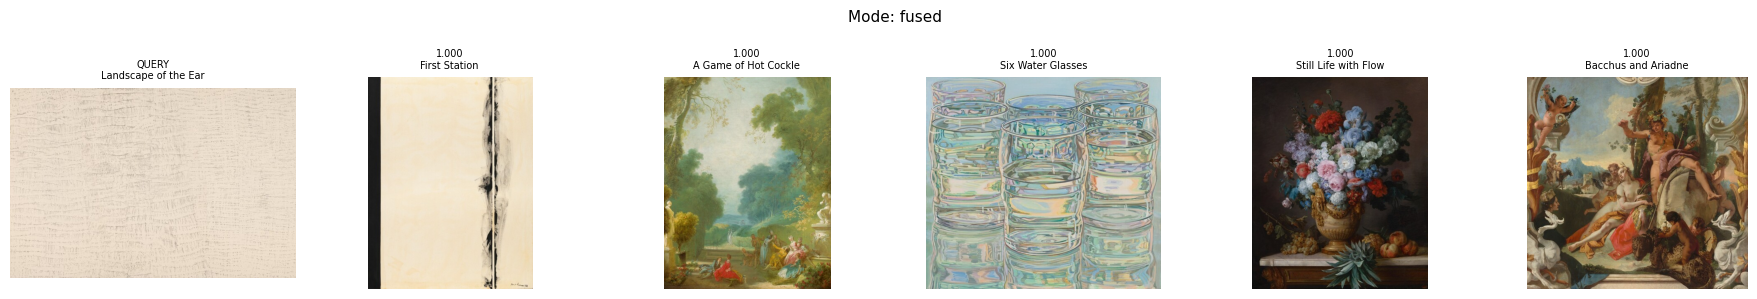

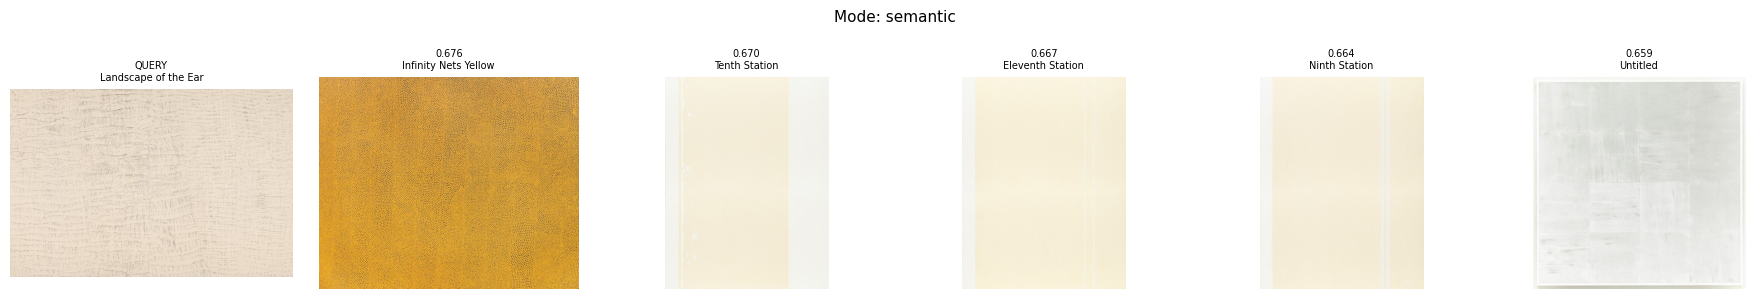

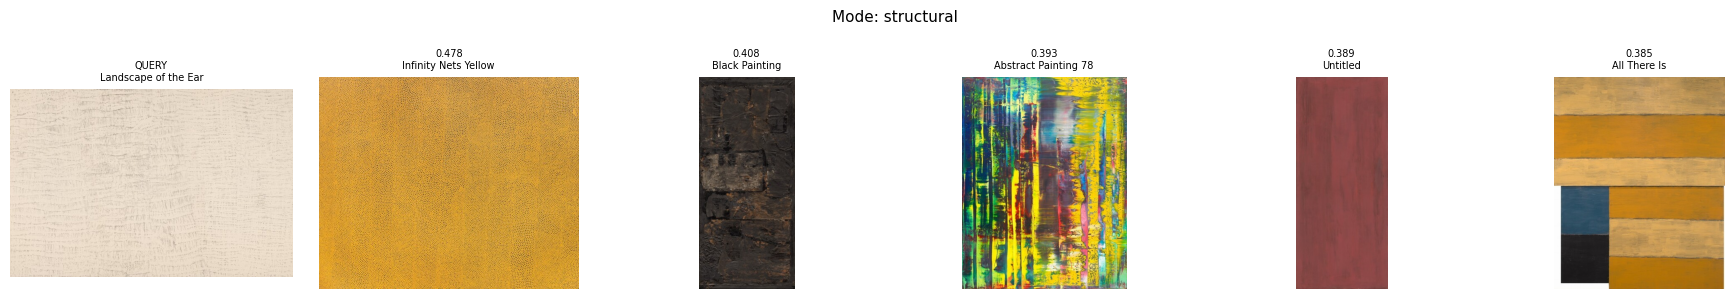

In [32]:
# ── Visualise results as a grid of images ─────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_grid(query_oid, results, mode='fused', n=5):
    qmeta = meta_dict.get(str(query_oid),{})
    fig, axes = plt.subplots(1, n+1, figsize=(3*(n+1), 3))
    fig.suptitle(f'Mode: {mode}', fontsize=11)
    # Query
    qpath = qmeta.get('local_path','')
    if qpath and Path(qpath).exists():
        axes[0].imshow(mpimg.imread(qpath))
    axes[0].set_title(f'QUERY\n{qmeta.get("title","")[:20]}', fontsize=7)
    axes[0].axis('off')
    # Results
    for i, r in enumerate(results[:n], 1):
        p = r.get('path','')
        if p and Path(p).exists(): axes[i].imshow(mpimg.imread(p))
        else: axes[i].set_facecolor('#eee')
        sim_str = f"{r['sim']:.3f}"
        axes[i].set_title(f'{sim_str}\n{r["title"][:20]}', fontsize=7)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

show_grid(sample_id, search(sample_id,'fused',5), mode='fused')
show_grid(sample_id, search(sample_id,'semantic',5), mode='semantic')
show_grid(sample_id, search(sample_id,'structural',5), mode='structural')

---
## Step 11 — Evaluation Metrics
Computes MAP@K, nDCG@K, Recall@K, Precision@1, and MRR for all three modes.
Ground truth: two paintings are relevant if they share at least one subject tag.

⏱ **~5 min**

In [33]:
# ── Build ground truth from subject tags ──────────────────────────────────
print('Building ground-truth relevance sets...')
tag_col = 'subjectterms' if 'subjectterms' in df.columns else 'classification'
df['objectid'] = df['objectid'].astype(str)

tag_to_ids = {}
for _, row in tqdm(df.iterrows(), total=len(df), desc='Tag index'):
    oid = str(row['objectid'])
    for t in str(row.get(tag_col,'')).lower().split('|'):
        t = t.strip()
        if t: tag_to_ids.setdefault(t,set()).add(oid)

ground_truth = {}
for _, row in tqdm(df.iterrows(), total=len(df), desc='Relevance sets'):
    oid = str(row['objectid'])
    rel = set()
    for t in str(row.get(tag_col,'')).lower().split('|'):
        t = t.strip()
        if t and t in tag_to_ids: rel |= tag_to_ids[t]
    rel.discard(oid)
    if rel: ground_truth[oid] = rel

print(f'Paintings with relevant matches: {len(ground_truth):,}')
print(f'Avg relevant per query: {np.mean([len(v) for v in ground_truth.values()]):.1f}')

Building ground-truth relevance sets...


Tag index:   0%|          | 0/4013 [00:00<?, ?it/s]

Relevance sets:   0%|          | 0/4013 [00:00<?, ?it/s]

Paintings with relevant matches: 4,013
Avg relevant per query: 4012.0


In [34]:
# ── Metric functions ──────────────────────────────────────────────────────
def ap_at_k(retrieved, relevant, k):
    if not relevant: return 0.
    ap, nr = 0., 0
    for i,r in enumerate(retrieved[:k],1):
        if r in relevant: nr+=1; ap+=nr/i
    return ap/min(len(relevant),k)

def recall_at_k(retrieved, relevant, k):
    if not relevant: return 0.
    return sum(1 for r in retrieved[:k] if r in relevant)/len(relevant)

def ndcg_at_k(retrieved, relevant, k):
    if not relevant: return 0.
    dcg  = sum(1./np.log2(i+1) for i,r in enumerate(retrieved[:k],1) if r in relevant)
    idcg = sum(1./np.log2(i+1) for i in range(1,min(len(relevant),k)+1))
    return dcg/idcg if idcg>0 else 0.

def mrr(retrieved, relevant):
    for i,r in enumerate(retrieved,1):
        if r in relevant: return 1./i
    return 0.

In [35]:
# ── Run evaluation for each mode ──────────────────────────────────────────
import json

valid_qids = [oid for oid in object_ids if oid in ground_truth]
n_queries  = min(EVAL_N_QUERIES, len(valid_qids))
query_ids  = random.sample(valid_qids, n_queries)
max_k      = max(EVAL_K_VALUES)

all_results = []
for mode in ['semantic','structural','fused']:
    embs    = mode_embeddings[mode]
    flat_ix = faiss.IndexFlatIP(embs.shape[1])
    flat_ix.add(embs)
    ap_s={k:[] for k in EVAL_K_VALUES}
    rc_s={k:[] for k in EVAL_K_VALUES}
    nd_s={k:[] for k in EVAL_K_VALUES}
    mrr_s=[]
    for qid in tqdm(query_ids, desc=f'Eval [{mode}]'):
        qrow = id_to_row.get(qid)
        if qrow is None: continue
        q_emb= embs[qrow:qrow+1].astype('float32')
        D,I  = flat_ix.search(q_emb, max_k+5)
        retr = []
        for ridx in I[0]:
            if ridx<0: continue
            rid = object_ids[int(ridx)]
            if rid!=qid: retr.append(rid)
            if len(retr)>=max_k: break
        rel = ground_truth[qid]
        mrr_s.append(mrr(retr,rel))
        for k in EVAL_K_VALUES:
            ap_s[k].append(ap_at_k(retr,rel,k))
            rc_s[k].append(recall_at_k(retr,rel,k))
            nd_s[k].append(ndcg_at_k(retr,rel,k))
    res = {'mode':mode, 'n_queries':n_queries, 'MRR':float(np.mean(mrr_s))}
    for k in EVAL_K_VALUES:
        res[f'MAP@{k}']    = float(np.mean(ap_s[k]))
        res[f'Recall@{k}'] = float(np.mean(rc_s[k]))
        res[f'nDCG@{k}']   = float(np.mean(nd_s[k]))
    all_results.append(res)

# Save
results_path = f'{RESULTS_DIR}/evaluation_results.json'
with open(results_path,'w') as f: json.dump(all_results,f,indent=2)
print(f'Results saved → {results_path}')

Eval [semantic]:   0%|          | 0/500 [00:00<?, ?it/s]

Eval [structural]:   0%|          | 0/500 [00:00<?, ?it/s]

Eval [fused]:   0%|          | 0/500 [00:00<?, ?it/s]

Results saved → /content/painting_similarity/results/evaluation_results.json


In [36]:
# ── Print results table ────────────────────────────────────────────────────
cols = ['Mode','MRR'] + [f'MAP@{k}' for k in EVAL_K_VALUES] + [f'nDCG@{k}' for k in EVAL_K_VALUES] + [f'Recall@{k}' for k in EVAL_K_VALUES]
W = 10
print('  '+''.join(f'{c:<{W}}' for c in cols))
print('  '+'─'*(W*len(cols)))
for r in all_results:
    row = [r['mode'], f"{r['MRR']:.4f}"]
    for k in EVAL_K_VALUES: row.append(f"{r.get(f'MAP@{k}',0):.4f}")
    for k in EVAL_K_VALUES: row.append(f"{r.get(f'nDCG@{k}',0):.4f}")
    for k in EVAL_K_VALUES: row.append(f"{r.get(f'Recall@{k}',0):.4f}")
    print('  '+''.join(f'{v:<{W}}' for v in row))

best = max(all_results, key=lambda r: r.get(f'MAP@{EVAL_K_VALUES[-1]}',0))
print(f"\n  Best mode: '{best['mode']}'  MAP@{EVAL_K_VALUES[-1]} = {best.get(f'MAP@{EVAL_K_VALUES[-1]}',0):.4f}")

  Mode      MRR       MAP@1     MAP@5     MAP@10    MAP@20    nDCG@1    nDCG@5    nDCG@10   nDCG@20   Recall@1  Recall@5  Recall@10 Recall@20 
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  semantic  1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    0.0002    0.0012    0.0025    0.0050    
  structural1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    0.0002    0.0012    0.0025    0.0050    
  fused     1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    0.0002    0.0012    0.0025    0.0050    

  Best mode: 'semantic'  MAP@20 = 1.0000


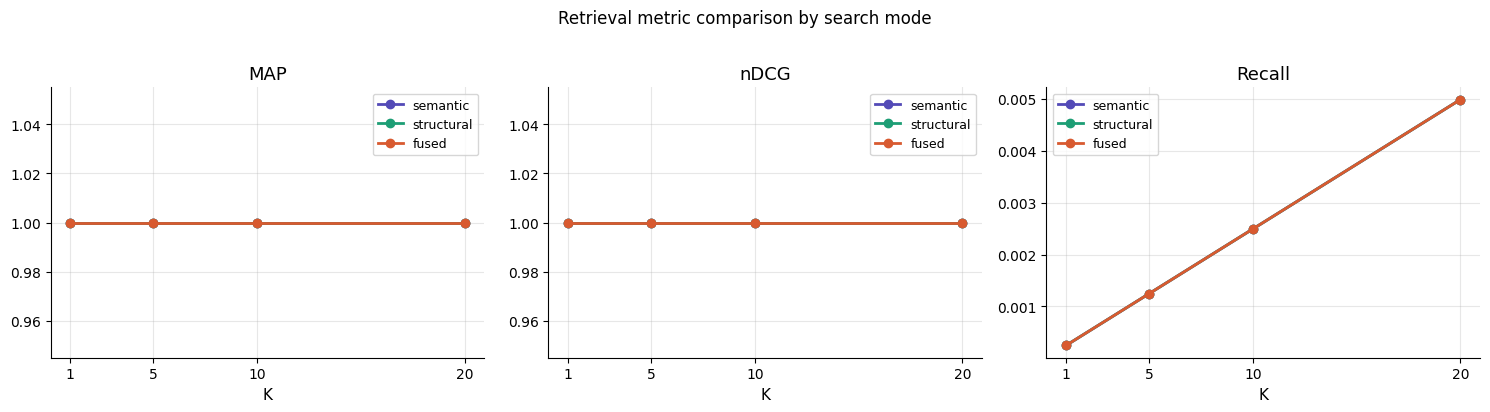

✓ Plot saved


In [37]:
# ── Plot metric comparison ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,3, figsize=(15,4))
metrics = ['MAP', 'nDCG', 'Recall']
colors  = ['#534AB7','#1D9E75','#D85A30']

for ax, metric in zip(axes, metrics):
    for res, col in zip(all_results, colors):
        vals = [res.get(f'{metric}@{k}',0) for k in EVAL_K_VALUES]
        ax.plot(EVAL_K_VALUES, vals, marker='o', label=res['mode'], color=col, linewidth=2)
    ax.set_title(metric, fontsize=13, fontweight='500')
    ax.set_xlabel('K', fontsize=11)
    ax.set_xticks(EVAL_K_VALUES)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Retrieval metric comparison by search mode', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Plot saved')

---
## Pipeline Complete

```
SimilaritySearch modes:
  'semantic'    → SigLIP only     (subject/content similarity)
  'structural'  → DINOv2 only     (pose/geometry similarity)
  'fused'       → all three       (recommended — best MAP@K)
```

Saved files:
- `embeddings/siglip_embeddings.npy` — SigLIP [N, 1024]
- `embeddings/dino_embeddings.npy`   — DINOv2 [N, 1024]
- `embeddings/pose_embeddings.npy`   — Pose   [N, 34]
- `embeddings/fused_embeddings.npy`  — Fused  [N, 512]
- `index/painting_index.faiss`       — FAISS IVF-PQ index
- `checkpoints/final_lora_adapter/`  — fine-tuned SigLIP LoRA weights
- `results/evaluation_results.json`  — full metric scores